In [5]:
# ===============================
# BLOK 1: DATALOADER (Resize dan Augmentasi saat Runtime)
# ===============================
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from glob import glob
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score
from tqdm import tqdm

# --- Variabel Lingkungan (DEVICE) ---
DEVICE = "cuda:1" if torch.cuda.is_available() else "cpu"
# DEVICE untuk Kode 1 asli adalah "cuda:1"
# DEVICE = "cuda:1" if torch.cuda.is_available() else "cpu" 
# Saya menggunakan "cuda" agar lebih umum, sesuaikan jika perlu.

# ==========================================
# 1.1 SIMPLE RESIZE 
# ==========================================
def simple_resize(image_bgr, size=224):
    """Mengubah ukuran gambar menjadi ukuran yang ditentukan (default 224x224)."""
    return cv2.resize(image_bgr, (size, size))

# ==========================================
# 1.3 Dataset & DataLoader 
# ==========================================
class FaceDataset(Dataset):
    def __init__(self, folder, is_train=False, target_size=224):
        self.paths = glob(os.path.join(folder, "**", "*.*"), recursive=True)
        self.target_size = target_size
        
        # --- Transformasi: Augmentasi untuk Train, Rescale untuk Val/Test ---
        if is_train:
            # Augmentasi: RandomHorizontalFlip, Rescale ke [0, 1]
            self.torch_trans = transforms.Compose([
                transforms.ToTensor(),             
                transforms.RandomHorizontalFlip(),  # Augmentasi
                # Catatan: Normalisasi (misal: mean/std ImageNet) harus ditambahkan di sini
            ])
        else:
            # Hanya Rescale ke [0, 1]
            self.torch_trans = transforms.Compose([
                transforms.ToTensor(),             
                # Catatan: Normalisasi (misal: mean/std ImageNet) harus ditambahkan di sini
            ])
        # ------------------------------------------------------------------

        # Menentukan label
        self.labels = []
        for p in self.paths:
            cls = os.path.basename(os.path.dirname(p))
            # Sesuaikan label: 0 untuk 'real', 1 untuk 'fake'
            label = 0 if cls == "real" else 1 
            self.labels.append(label)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = cv2.imread(path)
        
        if img is None:
            # Handle gambar yang gagal dimuat
            print(f"Warning: Failed to load image at {path}")
            # Mengembalikan tensor zero dan label 0 untuk mencegah crash DataLoader
            return torch.zeros((3, self.target_size, self.target_size), dtype=torch.float32), 0 

        # Terapkan Resize Sederhana 
        img = simple_resize(img, size=self.target_size)
        
        # OpenCV memuat sebagai BGR, harus diubah ke RGB sebelum ToTensor
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
        
        # Terapkan Transformasi dan Augmentasi
        # Perlu diubah ke format PIL Image jika menggunakan transforms.RandomHorizontalFlip()
        # atau gunakan transform kustom di numpy. Untuk menyederhanakan, kita asumsikan img sudah siap.
        img = self.torch_trans(img)
        label = self.labels[idx]
        return img, label


def create_dataloader(folder, batch_size=32, shuffle=True, is_train=False):
    ds = FaceDataset(folder, is_train=is_train) 
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=4, pin_memory=True)


# ==========================================
# 1.4 Run DataLoader (Membutuhkan Folder 'dataset' lokal)
# ==========================================
base_data_dir = "dataset" 
print("Mencoba membuat DataLoaders...")

try:
    # Coba inisialisasi DataLoaders
    train_loader = create_dataloader(os.path.join(base_data_dir, "train"), batch_size=64, shuffle=True, is_train=True)
    val_loader   = create_dataloader(os.path.join(base_data_dir, "valid"), batch_size=64, shuffle=False, is_train=False)
    test_loader  = create_dataloader(os.path.join(base_data_dir, "test"), batch_size=64, shuffle=False, is_train=False)

    print("\n✅ Pembuatan DataLoaders Selesai.")
    print(f"Total Train images: {len(train_loader.dataset)}")
    print(f"Total Valid images: {len(val_loader.dataset)}")
    print(f"Total Test images:  {len(test_loader.dataset)}")

except Exception as e:
    print(f"\n⚠️ WARNING: Gagal memuat DataLoader. Pastikan folder '{base_data_dir}' ada.")
    print(f"Error: {e}")
    # Jika gagal, definisikan sebagai None agar kode tidak crash
    train_loader, val_loader, test_loader = None, None, None

Mencoba membuat DataLoaders...

✅ Pembuatan DataLoaders Selesai.
Total Train images: 20000
Total Valid images: 2000
Total Test images:  2000


In [58]:
# ===============================
# FUNGSI DEFINISI MODEL (Model Factory)
# ===============================
def get_model_pytorch_updated(num_classes=2, conv_filters=512, drop_rate=0.7, learning_rate=1e-3):
    import torch.nn as nn
    from torchvision import models
    import torch

    class PyTorchModel(nn.Module):
        def __init__(self, backbone, conv_block, classifier_head):
            super().__init__()
            self.backbone = backbone
            self.conv_block = conv_block
            self.classifier_head = classifier_head

        def forward(self, x):
            x = self.backbone.features(x)
            x = self.conv_block(x)
            x = self.classifier_head(x)
            return x

    backbone = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
    )
    backbone.classifier = nn.Identity()

    for p in backbone.parameters():
        p.requires_grad = False

    IN_CHANNELS = 1280

    custom_conv_block = nn.Sequential(
        nn.Conv2d(IN_CHANNELS, conv_filters, kernel_size=3, padding='same'),
        nn.BatchNorm2d(conv_filters),
        nn.ReLU()
    )

    classifier_head = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(conv_filters, 256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(drop_rate),
        nn.Linear(256, num_classes)
    )

    model = PyTorchModel(backbone, custom_conv_block, classifier_head)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    return model, optimizer, criterion

In [29]:
# ===============================
# FUNGSI TRAINING
# ===============================
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, use_scheduler=True):
    import numpy as np
    import torch
    import torch.nn as nn
    from tqdm import tqdm
    from sklearn.metrics import f1_score

    device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.3, patience=2, verbose=True
    ) if use_scheduler else None

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": [],
        "lr": []
    }

    best_val_loss = np.inf
    patience_counter = 0
    patience_limit = 5

    print("\n===== 🚀 Training Dimulai =====")
    for epoch in range(1, epochs + 1):

        # ---------------- TRAIN ----------------
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []

        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)

            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        avg_train_loss = train_loss / len(train_loader.dataset)
        train_acc = np.mean(np.array(train_preds) == np.array(train_labels))
        train_f1 = f1_score(train_labels, train_preds, average="weighted")

        # ---------------- VAL ----------------
        model.eval()
        val_loss = 0
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Val]", leave=False):
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader.dataset)
        val_acc = np.mean(np.array(val_preds) == np.array(val_labels))
        val_f1 = f1_score(val_labels, val_preds, average="weighted")

        # ---------------- LR SCHEDULER ----------------
        if scheduler:
            scheduler.step(avg_val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch}: LR={current_lr:.8f} | "
            f"TrainLoss={avg_train_loss:.4f}, ValLoss={avg_val_loss:.4f}, "
            f"TrainAcc={train_acc:.4f}, ValAcc={val_acc:.4f}, "
            f"TrainF1={train_f1:.4f}, ValF1={val_f1:.4f}"
        )

        # ---------------- SAVE HISTORY ----------------
        history["epoch"].append(epoch)
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)
        history["lr"].append(current_lr)

        # ---------------- EARLY STOPPING ----------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0

            # === SIMPAN MODEL TERBAIK ===
            torch.save(model.state_dict(), "best_model_512_3x3_DO05.pth")
            print("💾 Model terbaik disimpan: best_model_512_3x3_DO05.pth")
        else:
            patience_counter += 1
            print(f"⚠️ Early Stopping Counter: {patience_counter}/{patience_limit}")

        if patience_counter >= patience_limit:
            print("⛔ Training dihentikan karena Early Stopping.")
            break

    print("===== ✅ Training Selesai =====")
    return history

In [34]:
# ===============================
# RUN SCRIPT
# ===============================
if train_loader is not None and val_loader is not None:
    model_pytorch, optimizer_used, _ = get_model_pytorch_updated(
        num_classes=2,
        conv_filters=512,
        drop_rate=0.6,
        learning_rate=1e-3
    )

    print(f"Learning Rate awal optimizer: {optimizer_used.param_groups[0]['lr']:.8f}")

    history = train_model(
        model_pytorch,
        train_loader,
        val_loader,
        epochs=50,
        lr=1e-3,
        use_scheduler=True
    )

/home/jupyter-herlinalim/.local/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Learning Rate awal optimizer: 0.00100000

===== 🚀 Training Dimulai =====


Epoch 1: LR=0.00100000 | TrainLoss=0.5138, ValLoss=0.4521, TrainAcc=0.7876, ValAcc=0.8305, TrainF1=0.7876, ValF1=0.8301
💾 Model terbaik disimpan: best_model_512_3x3_DO05.pth


Epoch 2: LR=0.00100000 | TrainLoss=0.4365, ValLoss=0.4345, TrainAcc=0.8478, ValAcc=0.8470, TrainF1=0.8478, ValF1=0.8467
💾 Model terbaik disimpan: best_model_512_3x3_DO05.pth


Epoch 3: LR=0.00100000 | TrainLoss=0.4079, ValLoss=0.4419, TrainAcc=0.8691, ValAcc=0.8500, TrainF1=0.8691, ValF1=0.8488
⚠️ Early Stopping Counter: 1/5


...

Epoch 14: LR=0.00030000 | TrainLoss=0.2662, ValLoss=0.3469, TrainAcc=0.9709, ValAcc=0.9155, TrainF1=0.9709, ValF1=0.9155
⚠️ Early Stopping Counter: 1/5


Epoch 15: LR=0.00030000 | TrainLoss=0.2641, ValLoss=0.3538, TrainAcc=0.9716, ValAcc=0.9090, TrainF1=0.9715, ValF1=0.9089
⚠️ Early Stopping Counter: 2/5


Epoch 16: LR=0.00009000 | TrainLoss=0.2609, ValLoss=0.3763, TrainAcc=0.9738, ValAcc=0.8940, TrainF1=0.9738, ValF1=0.8936
⚠️ Early Stopping Counter: 3/5


Epoch 17: LR=0.00009000 | TrainLoss=0.2481, ValLoss=0.3473, TrainAcc=0.9825, ValAcc=0.9125, TrainF1=0.9824, ValF1=0.9124
⚠️ Early Stopping Counter: 4/5


Epoch 18: LR=0.00009000 | TrainLoss=0.2460, ValLoss=0.3461, TrainAcc=0.9829, ValAcc=0.9180, TrainF1=0.9829, ValF1=0.9179
⚠️ Early Stopping Counter: 5/5
⛔ Training dihentikan karena Early Stopping.
===== ✅ Training Selesai =====


In [31]:
import pandas as pd

os.makedirs("results_history", exist_ok=True)
history_df = pd.DataFrame(history)
csv_path = "results_history/training_history_conv512_3x3_DO05.csv"
history_df.to_csv(csv_path, index=False)

print(f"\n✅ History training berhasil disimpan: {csv_path}")


✅ History training berhasil disimpan: results_history/training_history_conv512_3x3_DO05.csv


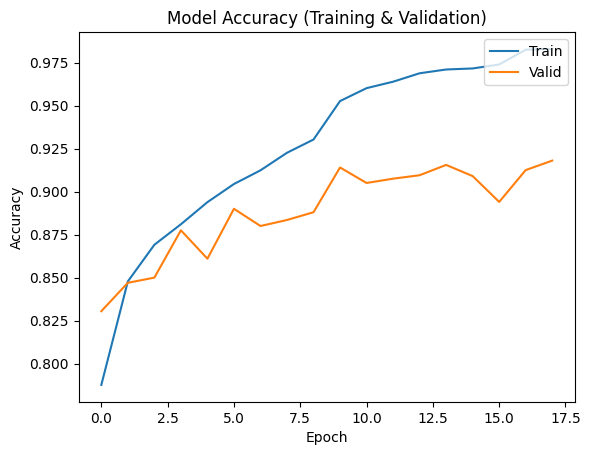

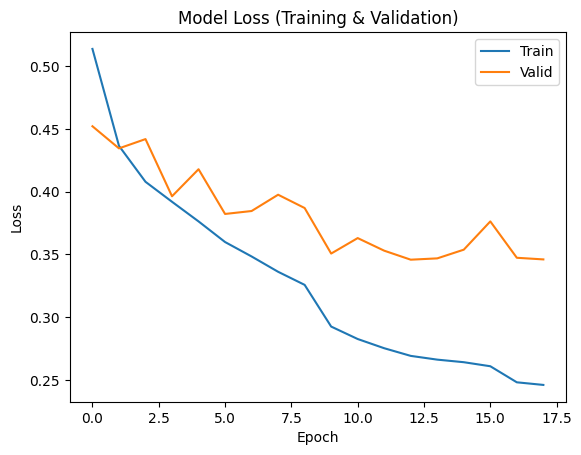

In [35]:
import matplotlib.pyplot as plt

# ========================
# Plot Accuracy
# ========================
plt.plot(history['train_acc'])
plt.plot(history['val_acc'])
plt.title('Model Accuracy (Training & Validation)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Valid'], loc='upper right')
plt.show()

# ========================
# Plot Loss
# ========================
plt.plot(history['train_loss'])
plt.plot(history['val_loss'])
plt.title('Model Loss (Training & Validation)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Valid'], loc='upper right')
plt.show()

Test Accuracy: 0.9255
Test F1 Score: 0.9264

Precision: 0.9151
Recall   : 0.9380
Classification Report:
              precision    recall  f1-score   support

        real       0.94      0.91      0.92      1000
        fake       0.92      0.94      0.93      1000

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



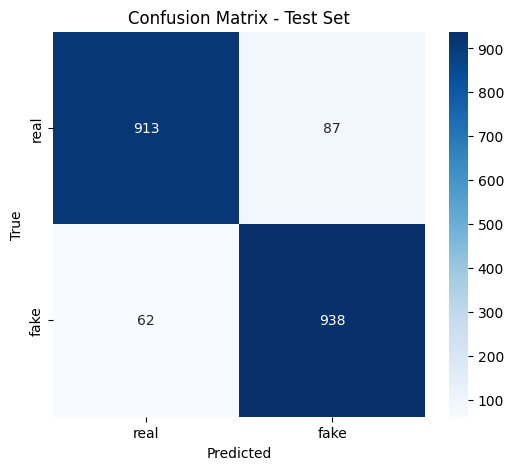

In [56]:
# ===============================
# BLOK 3: EVALUASI + METRICS
# ===============================
import torch
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

# =======================================================
# LOAD MODEL (HARUS SAMA DENGAN TRAINING)
# =======================================================
model, _, _ = get_model_pytorch_updated(
    num_classes=2,
    conv_filters=512,     
    drop_rate=0.7,
    learning_rate=1e-3
)

model.load_state_dict(torch.load("best_model_512_7x7.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()

# =======================================================
# EVALUASI TEST SET
# =======================================================
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# =======================================================
# METRICS
# =======================================================
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="binary")
recall    = recall_score(all_labels, all_preds, average="binary")

print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 Score: {f1:.4f}\n")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["real", "fake"]))


# =======================================================
# CONFUSION MATRIX
# =======================================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["real","fake"], yticklabels=["real","fake"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Test Set")
plt.show()

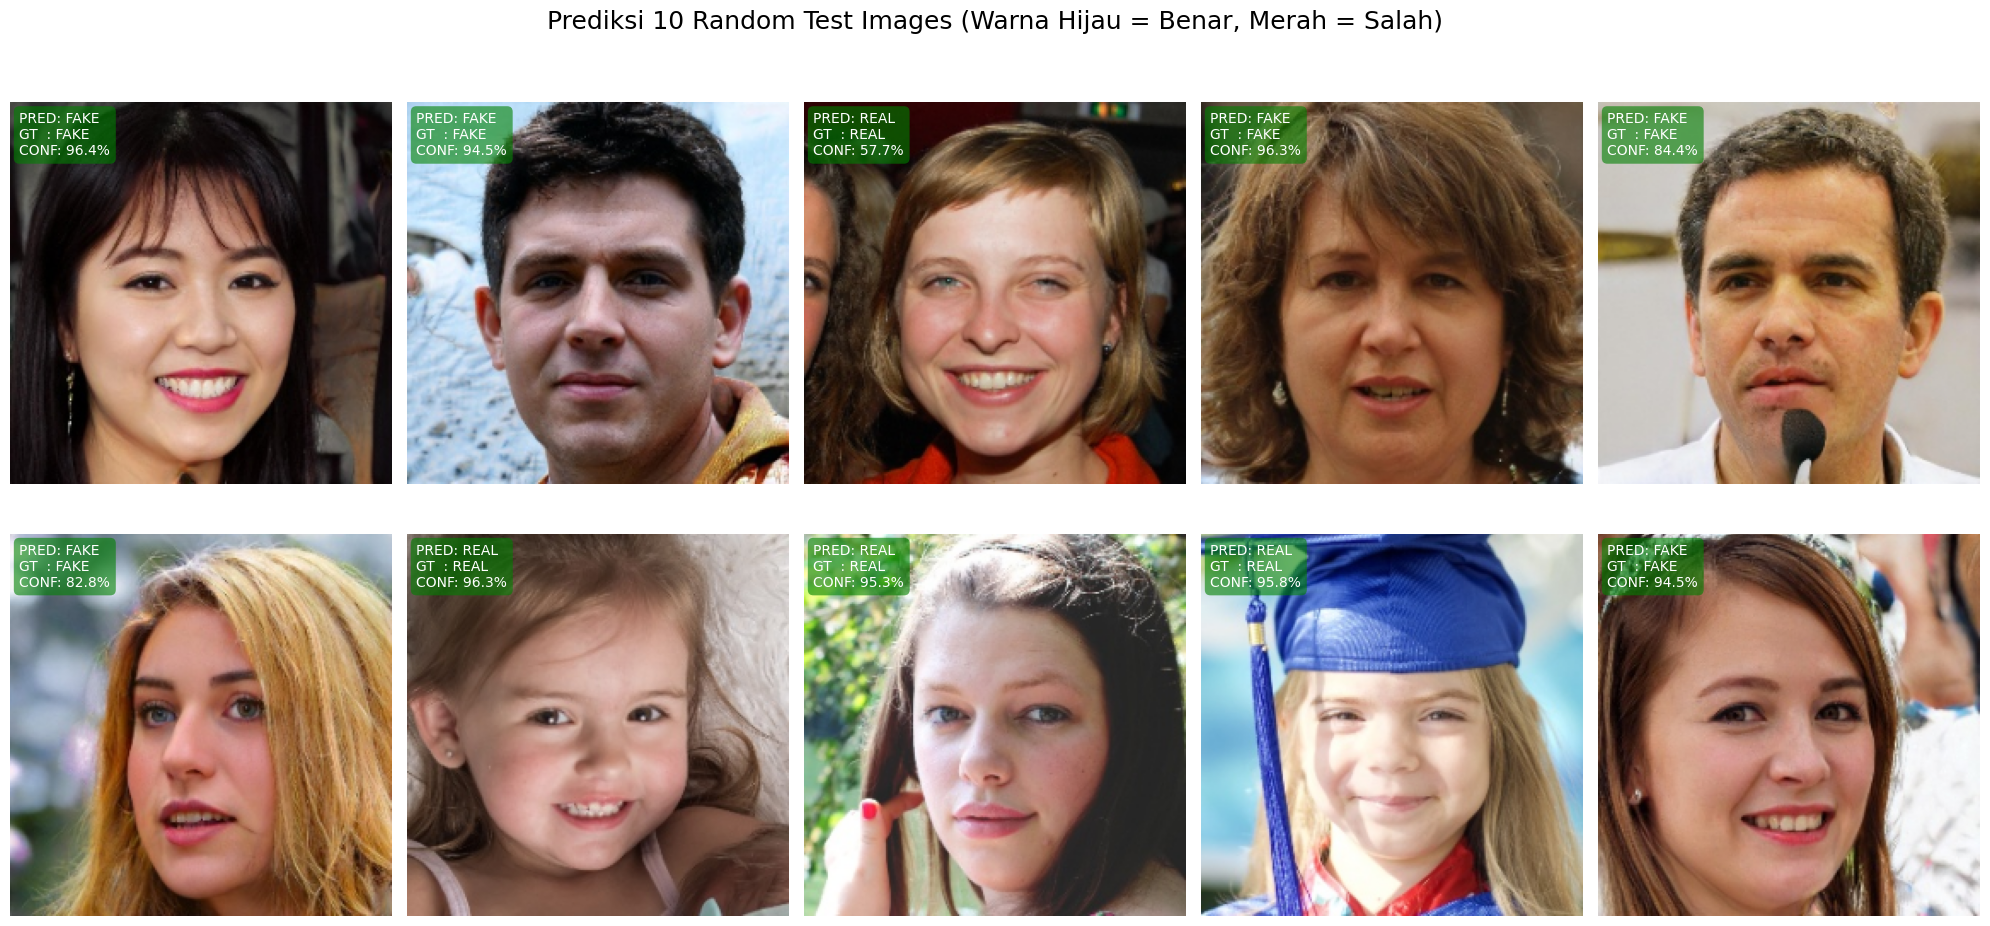

In [71]:
# ==========================================
# VISUALISASI DENGAN LABEL TRANSPARAN
# ==========================================
plt.figure(figsize=(20, 10))

for i in range(10):
    img = images[i].permute(1, 2, 0).cpu().numpy()
    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]
    confidence = conf[i] * 100

    # =============================
    # WARNA BERDASARKAN BENAR / SALAH
    # =============================
    if pred_label == true_label:
        color = "green"     # benar
    else:
        color = "red"       # salah

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis("off")

    ax = plt.gca()

    # ============================
    # LABEL TRANSPARAN
    # ============================
    label_text = (
        f"PRED: {pred_label.upper()}\n"
        f"GT  : {true_label.upper()}\n"
        f"CONF: {confidence:.1f}%"
    )

    ax.text(
        5, 5,
        label_text,
        fontsize=10,
        color="white",
        va="top",
        ha="left",
        bbox=dict(
            facecolor=color,
            alpha=0.6,       # Transparan
            edgecolor="none",
            boxstyle="round,pad=0.4"
        )
    )

plt.suptitle("Prediksi 10 Random Test Images (Warna Hijau = Benar, Merah = Salah)", fontsize=18)
plt.tight_layout()
plt.show()